In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
URL = "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/iris.csv"

In [2]:
from urllib.request import urlretrieve
urlretrieve(URL, "iris.csv")

('iris.csv', <http.client.HTTPMessage at 0x12b7ba110>)

In [3]:
#This code reads the data from a CSV file named "iris.csv" into a pandas DataFrame called data1
data1 = pd.read_csv("iris.csv", index_col="rownames")

In [4]:
data1

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
rownames,,,,,
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
146,6.7,3.0,5.2,2.3,virginica
147,6.3,2.5,5.0,1.9,virginica
148,6.5,3.0,5.2,2.0,virginica


/Users/gurbakshmunday/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


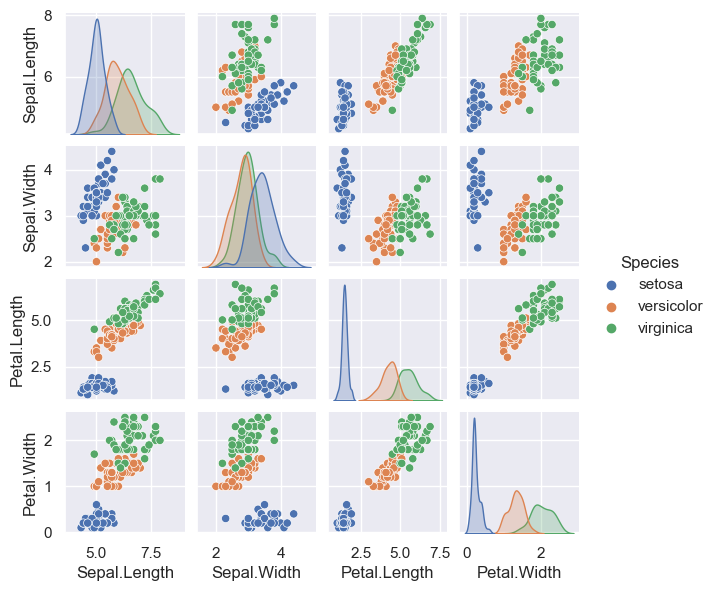

In [5]:
#creates the pairwise plot for the each column of the dataframe.
sns.set()
sns.pairplot(data1, hue = 'Species', height = 1.5)

In [6]:
#This code creates a new DataFrame X_iris by dropping the column 'Species'.
X_iris = data1.drop('Species', axis = 1)
X_iris.shape

(150, 4)

In [7]:
Y_iris = data1['Species']
Y_iris.shape

(150,)

In [8]:
Y_iris

rownames
1         setosa
2         setosa
3         setosa
4         setosa
5         setosa
         ...    
146    virginica
147    virginica
148    virginica
149    virginica
150    virginica
Name: Species, Length: 150, dtype: object

In [9]:
sepal_len = data1['Sepal.Length']
sepal_width = data1['Sepal.Width']

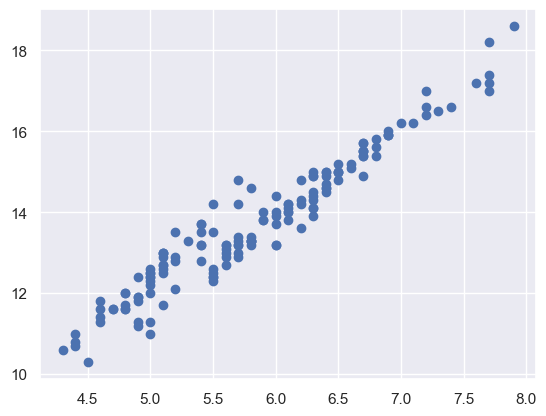

In [10]:
x = sepal_len
y = 2 * x - 1 + sepal_width
plt.scatter(x, y);

In [11]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X_iris, Y_iris, random_state=1)

In [12]:
ytest

rownames
15         setosa
99     versicolor
76     versicolor
17         setosa
132     virginica
57     versicolor
142     virginica
45         setosa
30         setosa
121     virginica
95     versicolor
6          setosa
103     virginica
52     versicolor
79     versicolor
43         setosa
93     versicolor
67     versicolor
32         setosa
36         setosa
91     versicolor
85     versicolor
78     versicolor
41         setosa
126     virginica
100    versicolor
34         setosa
20         setosa
74     versicolor
147     virginica
92     versicolor
136     virginica
70     versicolor
129     virginica
115     virginica
49         setosa
54     versicolor
29         setosa
Name: Species, dtype: object

In [13]:
from sklearn.naive_bayes import GaussianNB
model1 = GaussianNB()
model1.fit(Xtrain, ytrain)
Y_model = model1.predict(Xtest)

In [14]:
#provide the accuracy score of the code means how well it predict.
from sklearn.metrics import accuracy_score
accuracy_score(Y_model, ytest)

0.9736842105263158

In [15]:
from sklearn.decomposition import PCA
model = PCA(n_components = 2)
model.fit(X_iris)
X_2D = model.transform(X_iris)

/Users/gurbakshmunday/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


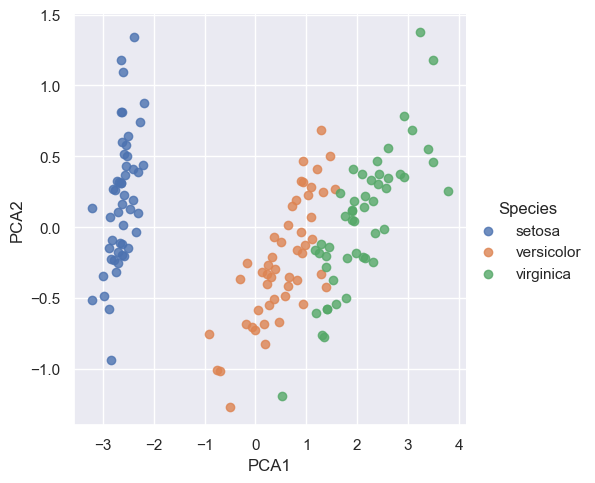

In [16]:
data1['PCA1'] = X_2D[:, 0]
data1['PCA2'] = X_2D[:, 1]
sns.lmplot(x = "PCA1", y = "PCA2", hue='Species', data=data1, fit_reg=False);

In [17]:
#This code applies Gaussian Mixture Model clustering with 3 components to the data in X_iris.
from sklearn.mixture import GaussianMixture
model2 = GaussianMixture(n_components = 3, covariance_type = 'full')
model2.fit(X_iris)
y_gm = model2.predict(X_iris)

/Users/gurbakshmunday/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


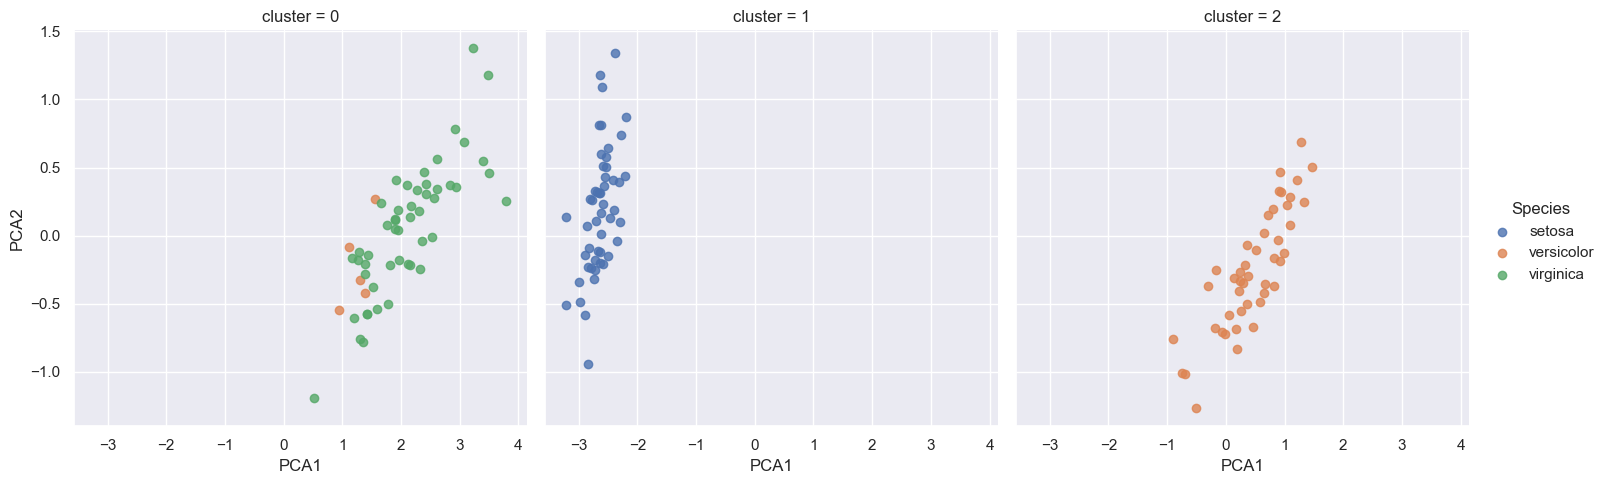

In [18]:
data1['cluster'] = y_gm
sns.lmplot(x= "PCA1", y = "PCA2", data = data1, hue = 'Species', 
          col = 'cluster', fit_reg = False);

This model showing the accuracy score level 0.97,which is a good score
but we can make this more accurate by providing the more detailed data.
